In [1]:
!pip install transformers torch pandas tqdm

In [2]:
import pandas as pd
from transformers import pipeline
from tqdm import tqdm

In [3]:
df = pd.read_csv(
    "dataset.csv",
    engine="python",
    on_bad_lines="skip",
    encoding="utf-8"
)

df = df[[
    "Text",
    "Score",
    "ProductId",
    "Summary",
    "HelpfulnessNumerator",
    "HelpfulnessDenominator"
]]

df = df.dropna(subset=["Text", "Score"])

df["Text"] = df["Text"].astype(str)
df["Score"] = df["Score"].astype(int)

df.head()

,Text,Score,ProductId,Summary,HelpfulnessNumerator,HelpfulnessDenominator
0,I have bought several of the Vitality canned d...,5,B001E4KFG0,Good Quality Dog Food,1,1
1,Product arrived labeled as Jumbo Salted Peanut...,1,B00813GRG4,Not as Advertised,0,0
2,This is a confection that has been around a fe...,4,B000LQOCH0,"""Delight"" says it all",1,1
3,If you are looking for the secret ingredient i...,2,B000UA0QIQ,Cough Medicine,3,3
4,Great taffy at a great price. There was a wid...,5,B006K2ZZ7K,Great taffy,0,0


In [4]:
def score_to_sentiment(score):
    if score > 3:
        return "POSITIVE"
    elif score < 3:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

df["actual_sentiment"] = df["Score"].apply(score_to_sentiment)

df["actual_sentiment"].value_counts()

,count
actual_sentiment,
POSITIVE,443777
NEGATIVE,82037
NEUTRAL,42640


In [5]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [6]:
df_sample = df.sample(5000, random_state=42).copy()

In [7]:
def get_bert_sentiment(text):
    result = sentiment_pipeline(str(text)[:512])[0]
    return result["label"], result["score"]

tqdm.pandas()

df_sample[["bert_label", "bert_confidence"]] = df_sample["Text"].progress_apply(
    lambda x: pd.Series(get_bert_sentiment(x))
)

df_sample.head()

100%|██████████| 5000/5000 [19:03<00:00,  4.37it/s]


,Text,Score,ProductId,Summary,HelpfulnessNumerator,HelpfulnessDenominator,actual_sentiment,bert_label,bert_confidence
165256,Having tried a couple of other brands of glute...,5,B000EVG8J2,Crunchy & Good Gluten-Free Sandwich Cookies!,0,0,POSITIVE,POSITIVE,0.999240
231465,My cat loves these treats. If ever I can't fin...,5,B0000BXJIS,great kitty treats,0,0,POSITIVE,POSITIVE,0.997516
427827,A little less than I expected. It tends to ha...,3,B008FHUFAU,COFFEE TASTE,0,2,NEUTRAL,NEGATIVE,0.999433
433954,"First there was Frosted Mini-Wheats, in origin...",2,B006BXV14E,So the Mini-Wheats were too big?,0,1,NEGATIVE,POSITIVE,0.937716
70260,and I want to congratulate the graphic artist ...,5,B007I7Z3Z0,Great Taste . . .,0,2,POSITIVE,POSITIVE,0.997636


In [8]:
df_eval = df_sample[df_sample["actual_sentiment"] != "NEUTRAL"].copy()

df_eval[["Score", "actual_sentiment", "bert_label", "bert_confidence", "Text"]].head()

,Score,actual_sentiment,bert_label,bert_confidence,Text
165256,5,POSITIVE,POSITIVE,0.999240,Having tried a couple of other brands of glute...
231465,5,POSITIVE,POSITIVE,0.997516,My cat loves these treats. If ever I can't fin...
433954,2,NEGATIVE,POSITIVE,0.937716,"First there was Frosted Mini-Wheats, in origin..."
70260,5,POSITIVE,POSITIVE,0.997636,and I want to congratulate the graphic artist ...
49866,4,POSITIVE,POSITIVE,0.995578,Please add more Pineapple flavor to your packa...


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(
    df_eval["actual_sentiment"],
    df_eval["bert_label"]
)

print("Accuracy:", accuracy)

print(classification_report(
    df_eval["actual_sentiment"],
    df_eval["bert_label"]
))

print(confusion_matrix(
    df_eval["actual_sentiment"],
    df_eval["bert_label"]
))

Accuracy: 0.8411942881869321
              precision    recall  f1-score   support

    NEGATIVE       0.49      0.90      0.63       703
    POSITIVE       0.98      0.83      0.90      3919

    accuracy                           0.84      4622
   macro avg       0.73      0.87      0.77      4622
weighted avg       0.90      0.84      0.86      4622

[[ 635   68]
 [ 666 3253]]


In [10]:
product_sentiment = df_sample.groupby("ProductId").agg(
    total_reviews=("bert_label", "count"),
    avg_bert_confidence=("bert_confidence", "mean"),
    positive_reviews=("bert_label", lambda x: (x == "POSITIVE").sum()),
    negative_reviews=("bert_label", lambda x: (x == "NEGATIVE").sum())
).reset_index()

product_sentiment["positive_sentiment_ratio"] = (
    product_sentiment["positive_reviews"] / product_sentiment["total_reviews"]
)

product_sentiment.head()

,ProductId,total_reviews,avg_bert_confidence,positive_reviews,negative_reviews,positive_sentiment_ratio
0,7310172001,1,0.998164,1,0,1.0
1,7310172101,2,0.987322,2,0,1.0
2,B00004CI84,2,0.862407,2,0,1.0
3,B00004CXX9,2,0.999082,2,0,1.0
4,B00004RAMS,1,0.998754,0,1,0.0


In [11]:
top_products = product_sentiment[
    product_sentiment["total_reviews"] >= 3
].sort_values(
    by="positive_sentiment_ratio",
    ascending=False
).head(10)

top_products

,ProductId,total_reviews,avg_bert_confidence,positive_reviews,negative_reviews,positive_sentiment_ratio
227,B0007A0AQW,5,0.998104,5,0,1.0
220,B0006Z7NOK,3,0.994886,3,0,1.0
154,B0002I0GUY,3,0.841101,3,0,1.0
140,B0002DGRRA,3,0.952215,3,0,1.0
226,B0007A0AQM,3,0.997923,3,0,1.0
309,B000BRR8VQ,5,0.992694,5,0,1.0
245,B000812K0O,4,0.983623,4,0,1.0
244,B0007XPS98,3,0.998105,3,0,1.0
345,B000CQC0BE,3,0.987302,3,0,1.0
700,B000GAT6MM,3,0.972973,3,0,1.0


In [12]:
worst_products = product_sentiment[
    product_sentiment["total_reviews"] >= 3
].sort_values(
    by="positive_sentiment_ratio",
    ascending=True
).head(10)

worst_products

,ProductId,total_reviews,avg_bert_confidence,positive_reviews,negative_reviews,positive_sentiment_ratio
1225,B000WFKI82,4,0.950010,0,4,0.000000
1233,B000WFORH0,3,0.995644,0,3,0.000000
848,B000JOE224,5,0.986992,0,5,0.000000
823,B000IHNCQO,3,0.969963,0,3,0.000000
3157,B004JRXZKM,3,0.995110,0,3,0.000000
3742,B008EG58V8,3,0.959778,0,3,0.000000
2698,B003BJZMSM,3,0.978789,0,3,0.000000
2973,B0041NYV8E,7,0.975142,1,6,0.142857
332,B000CNB4LE,5,0.987372,1,4,0.200000
884,B000KV7ZGQ,4,0.983664,1,3,0.250000


In [14]:
df_sample.to_csv("bert_pretrained_sentiment_results_5000_rows.csv", index=False)

In [17]:
df_sample[[
    "Score",
    "actual_sentiment",
    "bert_label",
    "bert_confidence",
    "Summary",
    "Text"
]].head()

,Score,actual_sentiment,bert_label,bert_confidence,Summary,Text
165256,5,POSITIVE,POSITIVE,0.999240,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
231465,5,POSITIVE,POSITIVE,0.997516,great kitty treats,My cat loves these treats. If ever I can't fin...
427827,3,NEUTRAL,NEGATIVE,0.999433,COFFEE TASTE,A little less than I expected. It tends to ha...
433954,2,NEGATIVE,POSITIVE,0.937716,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
70260,5,POSITIVE,POSITIVE,0.997636,Great Taste . . .,and I want to congratulate the graphic artist ...


In [18]:
df_eval = df_sample[df_sample["actual_sentiment"] != "NEUTRAL"].copy()

df_eval[["actual_sentiment", "bert_label"]].head()

,actual_sentiment,bert_label
165256,POSITIVE,POSITIVE
231465,POSITIVE,POSITIVE
433954,NEGATIVE,POSITIVE
70260,POSITIVE,POSITIVE
49866,POSITIVE,POSITIVE


In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(
    df_eval["actual_sentiment"],
    df_eval["bert_label"]
)

print("BERT Accuracy:", round(accuracy, 4))

print(classification_report(
    df_eval["actual_sentiment"],
    df_eval["bert_label"]
))

cm = confusion_matrix(
    df_eval["actual_sentiment"],
    df_eval["bert_label"],
    labels=["NEGATIVE", "POSITIVE"]
)

cm

BERT Accuracy: 0.8412
              precision    recall  f1-score   support

    NEGATIVE       0.49      0.90      0.63       703
    POSITIVE       0.98      0.83      0.90      3919

    accuracy                           0.84      4622
   macro avg       0.73      0.87      0.77      4622
weighted avg       0.90      0.84      0.86      4622



array([[ 635,   68],
       [ 666, 3253]])

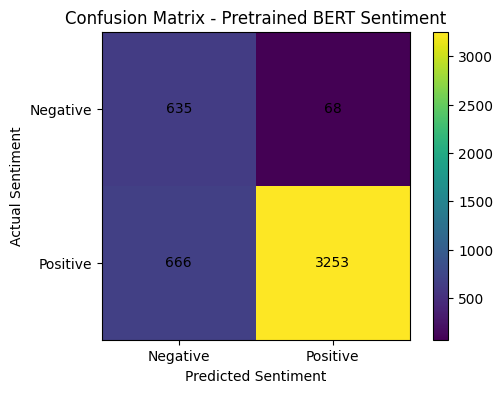

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.imshow(cm)

plt.title("Confusion Matrix - Pretrained BERT Sentiment")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

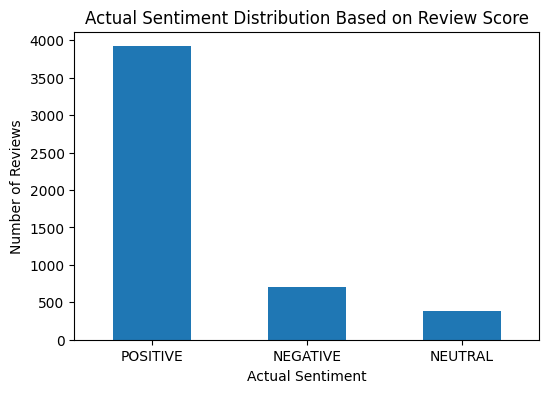

In [21]:
actual_counts = df_sample["actual_sentiment"].value_counts()

plt.figure(figsize=(6, 4))
actual_counts.plot(kind="bar")

plt.title("Actual Sentiment Distribution Based on Review Score")
plt.xlabel("Actual Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

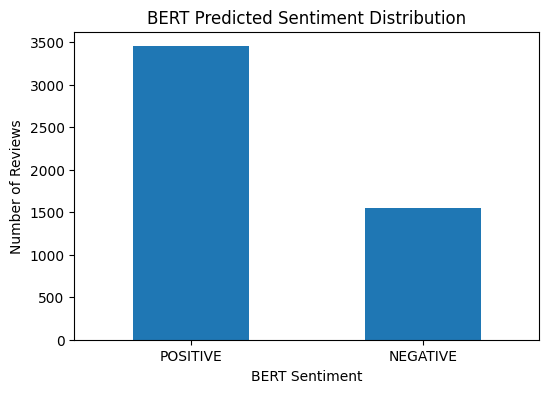

In [22]:
bert_counts = df_sample["bert_label"].value_counts()

plt.figure(figsize=(6, 4))
bert_counts.plot(kind="bar")

plt.title("BERT Predicted Sentiment Distribution")
plt.xlabel("BERT Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [23]:
comparison_counts = pd.crosstab(
    df_eval["actual_sentiment"],
    df_eval["bert_label"]
)

comparison_counts

bert_label,NEGATIVE,POSITIVE
actual_sentiment,,
NEGATIVE,635,68
POSITIVE,666,3253


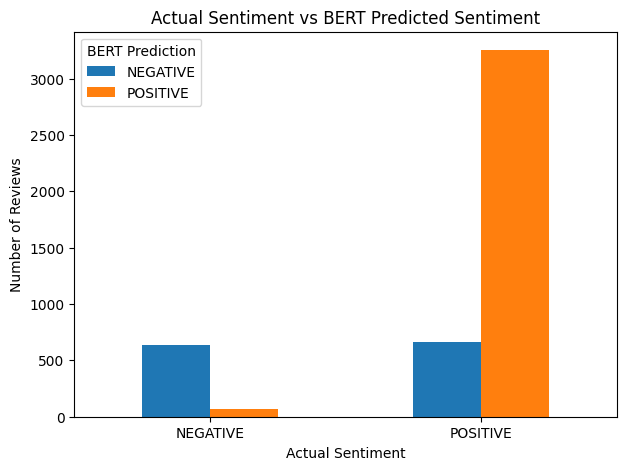

In [24]:
comparison_counts.plot(kind="bar", figsize=(7, 5))

plt.title("Actual Sentiment vs BERT Predicted Sentiment")
plt.xlabel("Actual Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="BERT Prediction")
plt.show()

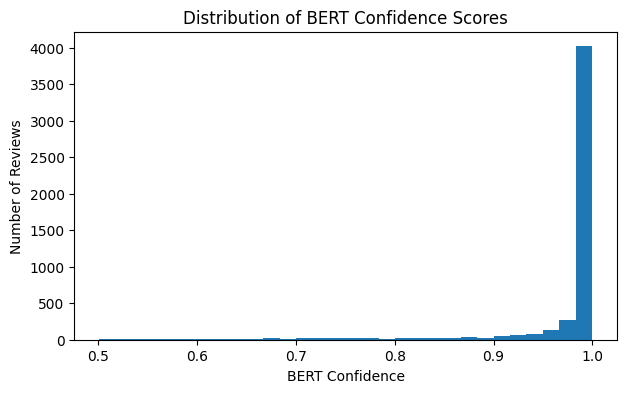

In [25]:
plt.figure(figsize=(7, 4))

plt.hist(df_sample["bert_confidence"], bins=30)

plt.title("Distribution of BERT Confidence Scores")
plt.xlabel("BERT Confidence")
plt.ylabel("Number of Reviews")
plt.show()

<Figure size 700x400 with 0 Axes>

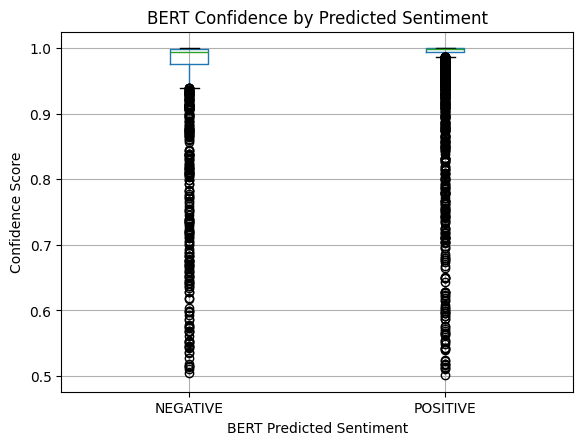

In [26]:
plt.figure(figsize=(7, 4))

df_sample.boxplot(
    column="bert_confidence",
    by="bert_label"
)

plt.title("BERT Confidence by Predicted Sentiment")
plt.suptitle("")
plt.xlabel("BERT Predicted Sentiment")
plt.ylabel("Confidence Score")
plt.show()

In [27]:
wrong_predictions = df_eval[
    df_eval["actual_sentiment"] != df_eval["bert_label"]
].copy()

wrong_predictions[[
    "Score",
    "actual_sentiment",
    "bert_label",
    "bert_confidence",
    "Summary",
    "Text"
]].head(10)

,Score,actual_sentiment,bert_label,bert_confidence,Summary,Text
433954,2,NEGATIVE,POSITIVE,0.937716,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
138968,4,POSITIVE,NEGATIVE,0.993550,Pretty good rice noodles,"Previously, I've attempted a recipe with white..."
492897,1,NEGATIVE,POSITIVE,0.998766,Beware! Flavored Coffee...,It sure would be nice if they stated ANYWHERE ...
179195,4,POSITIVE,NEGATIVE,0.810710,Re-Rating,"Okay, I jumped the gun, because they were send..."
203992,5,POSITIVE,NEGATIVE,0.971031,Very Impressed,"After a lot of research, i decided to switch m..."
488357,5,POSITIVE,NEGATIVE,0.999400,Coffee Pod Shipment,We recommend buying the coffee pods through Am...
545585,5,POSITIVE,NEGATIVE,0.993621,Never leave home w/o it !,I bought this online because I couldn't find i...
357330,5,POSITIVE,NEGATIVE,0.993089,Old Boy's Easy Bacalo,"I am the family butcher who at home, salt-cure..."
1533,4,POSITIVE,NEGATIVE,0.518084,Good but way too expensive,"Good product and decent shipping. However, the..."
188260,5,POSITIVE,NEGATIVE,0.995542,Just what I wanted,I very much enjoy dark roasts. The challenge ...


In [28]:
correct_predictions = df_eval[
    df_eval["actual_sentiment"] == df_eval["bert_label"]
].copy()

correct_predictions = correct_predictions.sort_values(
    by="bert_confidence",
    ascending=False
)

correct_predictions[[
    "Score",
    "actual_sentiment",
    "bert_label",
    "bert_confidence",
    "Summary",
    "Text"
]].head(10)

,Score,actual_sentiment,bert_label,bert_confidence,Summary,Text
449196,5,POSITIVE,POSITIVE,0.999892,delicious cake,"my experience with "" Omaha"" it is very good, t..."
457414,5,POSITIVE,POSITIVE,0.999891,Great Dog food,"This is great dog food. My golden loves it, he..."
30874,4,POSITIVE,POSITIVE,0.999888,Great Flavor,This flavor is very good and unexpected. The ...
112171,5,POSITIVE,POSITIVE,0.999888,The Most Delicious Honey!,This is a most delicious and vivid tasting hon...
567564,5,POSITIVE,POSITIVE,0.999888,Almost like a cinnamon roll,These Kashi bars are wonderful. Heat them a l...
523031,5,POSITIVE,POSITIVE,0.999888,Delicious tea,I'm a fan of flowery teas and this is definite...
329556,5,POSITIVE,POSITIVE,0.999888,Greenies,Thank you so much for sending us this product ...
395714,5,POSITIVE,POSITIVE,0.999887,My favorite Keurig K-cup!!!,This is my favorite flavor for my Keurig - smo...
197669,5,POSITIVE,POSITIVE,0.999887,ALBA BOTANICA PAPAYA ENZYME FACIAL MASK,AMAZING! I love this stuff! Uncovers glowing...
234370,5,POSITIVE,POSITIVE,0.999886,"Wonderful, full flavor tea!","Excellent tea! Hot or Iced, the full and smoo..."


In [29]:
product_sentiment = df_sample.groupby("ProductId").agg(
    total_reviews=("bert_label", "count"),
    positive_reviews=("bert_label", lambda x: (x == "POSITIVE").sum()),
    negative_reviews=("bert_label", lambda x: (x == "NEGATIVE").sum()),
    avg_bert_confidence=("bert_confidence", "mean")
).reset_index()

product_sentiment["positive_sentiment_ratio"] = (
    product_sentiment["positive_reviews"] / product_sentiment["total_reviews"]
)

product_sentiment.head()

,ProductId,total_reviews,positive_reviews,negative_reviews,avg_bert_confidence,positive_sentiment_ratio
0,7310172001,1,1,0,0.998164,1.0
1,7310172101,2,2,0,0.987322,1.0
2,B00004CI84,2,2,0,0.862407,1.0
3,B00004CXX9,2,2,0,0.999082,1.0
4,B00004RAMS,1,0,1,0.998754,0.0


In [30]:
top_products = product_sentiment[
    product_sentiment["total_reviews"] >= 3
].sort_values(
    by="positive_sentiment_ratio",
    ascending=False
).head(10)

top_products

,ProductId,total_reviews,positive_reviews,negative_reviews,avg_bert_confidence,positive_sentiment_ratio
227,B0007A0AQW,5,5,0,0.998104,1.0
220,B0006Z7NOK,3,3,0,0.994886,1.0
154,B0002I0GUY,3,3,0,0.841101,1.0
140,B0002DGRRA,3,3,0,0.952215,1.0
226,B0007A0AQM,3,3,0,0.997923,1.0
309,B000BRR8VQ,5,5,0,0.992694,1.0
245,B000812K0O,4,4,0,0.983623,1.0
244,B0007XPS98,3,3,0,0.998105,1.0
345,B000CQC0BE,3,3,0,0.987302,1.0
700,B000GAT6MM,3,3,0,0.972973,1.0


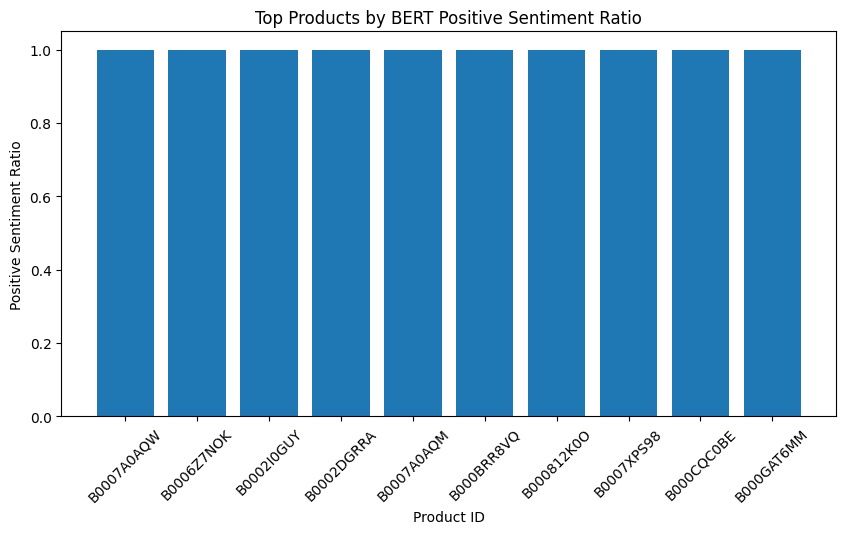

In [31]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_products["ProductId"],
    top_products["positive_sentiment_ratio"]
)

plt.title("Top Products by BERT Positive Sentiment Ratio")
plt.xlabel("Product ID")
plt.ylabel("Positive Sentiment Ratio")
plt.xticks(rotation=45)
plt.show()

In [32]:
worst_products = product_sentiment[
    product_sentiment["total_reviews"] >= 3
].sort_values(
    by="positive_sentiment_ratio",
    ascending=True
).head(10)

worst_products

,ProductId,total_reviews,positive_reviews,negative_reviews,avg_bert_confidence,positive_sentiment_ratio
1225,B000WFKI82,4,0,4,0.950010,0.000000
1233,B000WFORH0,3,0,3,0.995644,0.000000
848,B000JOE224,5,0,5,0.986992,0.000000
823,B000IHNCQO,3,0,3,0.969963,0.000000
3157,B004JRXZKM,3,0,3,0.995110,0.000000
3742,B008EG58V8,3,0,3,0.959778,0.000000
2698,B003BJZMSM,3,0,3,0.978789,0.000000
2973,B0041NYV8E,7,1,6,0.975142,0.142857
332,B000CNB4LE,5,1,4,0.987372,0.200000
884,B000KV7ZGQ,4,1,3,0.983664,0.250000


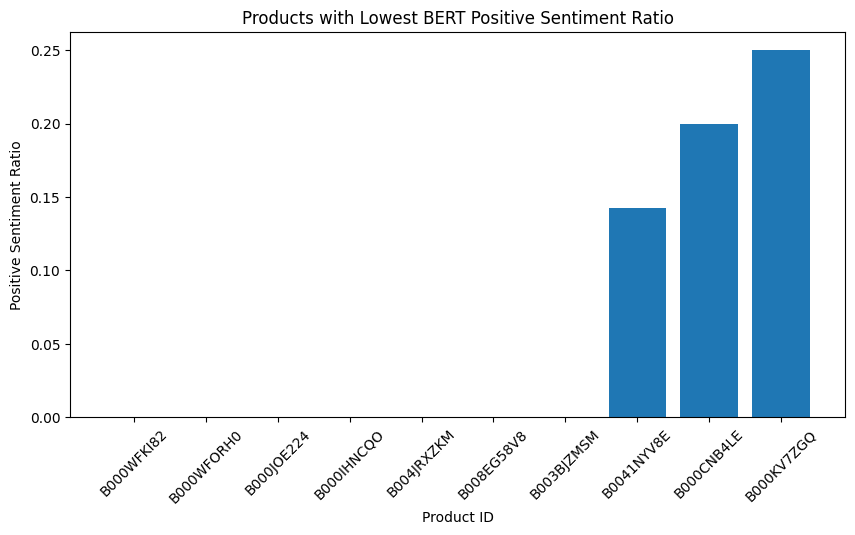

In [33]:
plt.figure(figsize=(10, 5))

plt.bar(
    worst_products["ProductId"],
    worst_products["positive_sentiment_ratio"]
)

plt.title("Products with Lowest BERT Positive Sentiment Ratio")
plt.xlabel("Product ID")
plt.ylabel("Positive Sentiment Ratio")
plt.xticks(rotation=45)
plt.show()